In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'

In [6]:
data = pd.read_csv(r"/home/lero/idrive/cmac/DDMAP/Stability studies/Stability_dataset_August_update.csv", na_values='nan')
data = data.drop(data.columns[0:7], axis=1)
data.drop(['Unnamed: 209', 'Unnamed: 210', 'Unnamed: 0'], axis=1, inplace=True)
#drop conditions since these have been split into temp/ humidity

#fill pure api with 0 for polymer mol desc
pure = data['Polymer']=='Pure'
polymer_descriptors = data.columns[219:]
data.loc[pure, polymer_descriptors] = 0

original_API=data['API']
original_condition = data['condition']
original_polymer = data['Polymer']
original_DL = data['Drug loading (wt%)']
original_stability = data['Average days stable']
Original_GFA = data['GFA']

data.drop(['condition'], axis=1, inplace=True)

data.fillna(data.mean(numeric_only=True), inplace=True)

data.head()

,Average days stable,API,Polymer,Drug loading (wt%),GFA,Tm (°C),Tg (°C),ΔHfus (kJ mol–1),ΔSfus × 10–2 (kJ mol–1 K–1),MaxAbsEStateIndex_x,...,fr_sulfide_y,fr_sulfonamd_y,fr_sulfone_y,fr_term_acetylene_y,fr_tetrazole_y,fr_thiazole_y,fr_thiocyan_y,fr_thiophene_y,fr_unbrch_alkane_y,fr_urea_y
0,1080.000000,Acetaminophen,Affinisol,80,2.0,166.0,25.2,39.272748,7.892092,10.524469,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1081.225694,Acetaminophen,Affinisol,70,2.0,166.0,25.2,39.272748,7.892092,10.524469,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1081.225694,Acetaminophen,Affinisol,60,2.0,166.0,25.2,39.272748,7.892092,10.524469,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2160.000000,Acetaminophen,Affinisol,50,2.0,166.0,25.2,39.272748,7.892092,10.524469,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2160.000000,Acetaminophen,Affinisol,40,2.0,166.0,25.2,39.272748,7.892092,10.524469,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
label_encoder=LabelEncoder()

data['API']=label_encoder.fit_transform(data['API'])
data['Polymer']=label_encoder.fit_transform(data['Polymer'])

pca_data = data

In [46]:
scalar = StandardScaler()
scaled_features = scalar.fit_transform(pca_data)

pca = PCA()  
principal_components = pca.fit_transform(scaled_features)

explained_variance_ratio = pca.explained_variance_ratio_

count = 0
for x in pca.explained_variance_ratio_:
    if x > 0:
        count +=1
print(f"total principal components above 0%: {count}")

top_50 = sum(explained_variance_ratio[:50]*100)
print(top_50)


total principal components above 0%: 215
99.99999999999964


In [49]:
rows = []
no_of_components = [10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 100]
for i in no_of_components:
    x = sum(explained_variance_ratio[:i]*100)
    rows.append({"number of components": i, "total variance": x})

total_variance = pd.DataFrame(rows)
print(total_variance)

    number of components  total variance
0                     10       78.275828
1                     15       86.903345
2                     20       92.567448
3                     25       96.362643
4                     30       98.723178
5                     35       99.789952
6                     40      100.000000
7                     45      100.000000
8                     50      100.000000
9                     60      100.000000
10                    70      100.000000
11                   100      100.000000


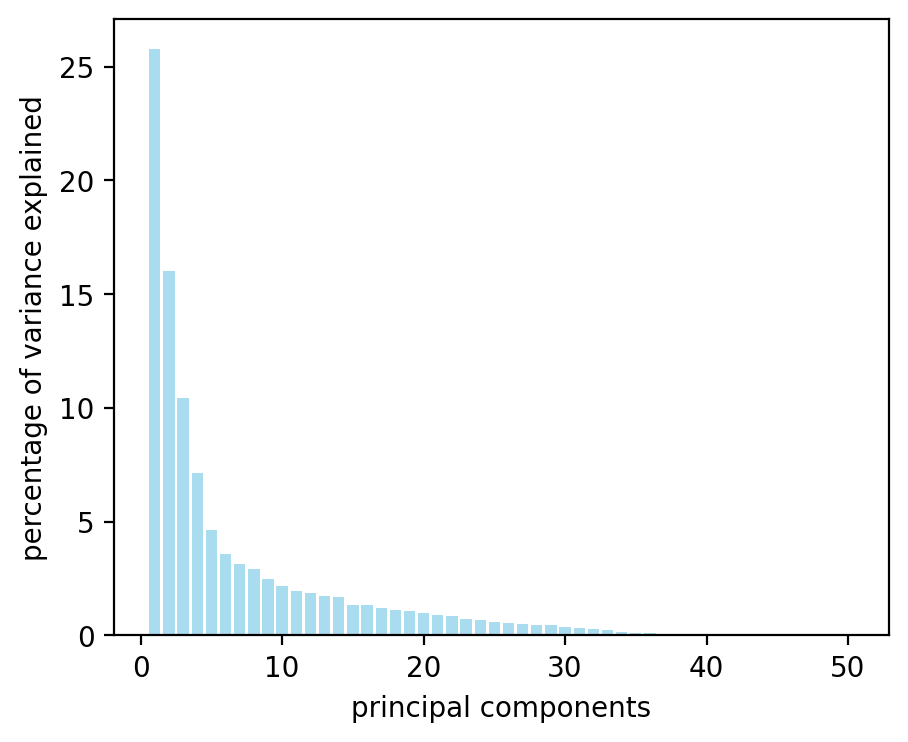

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50]


In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4), dpi=200)
component_index = np.arange(1, len(explained_variance_ratio) +1)
top_fifty = component_index[:50]
explained_var_50 = explained_variance_ratio[:50]*100
explained_var_of_top_50 = sum(top_fifty)
plt.bar(top_fifty, explained_var_50, color='skyblue', alpha=0.7)
plt.xlabel("principal components")
plt.ylabel("percentage of variance explained")
plt.show()

